# Parts of speech: the Genoese dialect
### Sara Caviglia - saracaviglia@hotmail.com

This notebook contains the code used for the Natural Language Processing's project.

## Imports and preprocessing

In [1]:
import pandas as pd
import nltk
import spacy
import matplotlib.pyplot as plt

In [2]:
text1 = open('../no_titles/OZina_1_Lij.txt', 'r', encoding='utf-8').read()
text2 = open('../no_titles/OZina_2_Lij.txt', 'r', encoding='utf-8').read()
text3 = open('../no_titles/OZina_3_Lij.txt', 'r', encoding='utf-8').read()
final = text1 + '\n\n' + text2 + '\n\n' + text3

with open('../text.txt', 'w', encoding='utf-8') as f:
	f.write(final)

### Genoese

In [3]:
nltk.download('punkt')
sentences = nltk.sent_tokenize(final)
rows = []
for sentence in sentences:
	tokens = nltk.word_tokenize(sentence)
	for word in tokens:
		rows.append({
			'SENTENCE': sentence,
			'TEXT': word,
			'POS_GROUPED': None
		})

genoese = pd.DataFrame(rows)

# save to csv
genoese.to_csv('../csv/postagging_genoese_SENTENCES.csv', index=False)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# creation of the Genoese csv with the correct structure

df_pos = pd.read_csv('../csv/postagging_genoese.csv')
df_sent = pd.read_csv('../csv/postagging_genoese_SENTENCES.csv')

df_sent['original_order'] = range(len(df_sent)) # to maintain the original order of the sentences

if 'POS_GROUPED' in df_sent.columns: 
    df_sent = df_sent.drop(columns=['POS_GROUPED']) # removed to avoid confusion

# used to create a unique identifier for each word in the sentence, allowing us to merge the two dataframes correctly
df_pos['word_instance'] = df_pos.groupby('TEXT').cumcount()
df_sent['word_instance'] = df_sent.groupby('TEXT').cumcount()

genoese = pd.merge(df_sent, df_pos, on=['TEXT', 'word_instance'], how='left')

genoese = genoese.sort_values('original_order') # to maintain the original order of the sentences
genoese = genoese.drop(columns=['word_instance', 'original_order']) # remove technical columns

genoese.to_csv('../csv/postagging_genoese_ORDINATO.csv', index=False) # save the final dataframe

genoese.head()

,SENTENCE,TEXT,POS_GROUPED
0,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,PRON
1,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,NOUN
2,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,NOUN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT
4,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,PRON


### Italian

In [5]:
nlp = spacy.load("it_core_news_sm", disable=["parser"])
sentences = nltk.sent_tokenize(final, language='italian')

rows = []

for sent_text in sentences:
	doc_sent = nlp(sent_text)
	for token in doc_sent:
		rows.append({
			'SENTENCE': sent_text,
			'TEXT': token.text,
			'POS': token.pos_
		})

italian = pd.DataFrame(rows, columns=['SENTENCE', 'TEXT', 'POS'])
italian.head()

,SENTENCE,TEXT,POS
0,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,PROPN
1,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,PROPN
2,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,PROPN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT
4,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,CCONJ


### French

In [6]:
nlp = spacy.load("fr_core_news_sm", disable=["parser"])
sentences = nltk.sent_tokenize(final, language='french')

rows = []

for sent_text in sentences:
	doc_sent = nlp(sent_text)
	for token in doc_sent:
		rows.append({
			'SENTENCE': sent_text,
			'TEXT': token.text,
			'POS': token.pos_
		})

french = pd.DataFrame(rows, columns=['SENTENCE', 'TEXT', 'POS'])
french.head()

,SENTENCE,TEXT,POS
0,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,NOUN
1,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,PROPN
2,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,PROPN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT
4,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,ADP


### Portuguese

In [7]:
nlp = spacy.load("pt_core_news_sm", disable=["parser"])
sentences = nltk.sent_tokenize(final, language='portuguese')

rows = []

for sent_text in sentences:
	doc_sent = nlp(sent_text)
	for token in doc_sent:
		rows.append({
			'SENTENCE': sent_text,
			'TEXT': token.text,
			'POS': token.pos_
		})

portuguese = pd.DataFrame(rows, columns=['SENTENCE','TEXT', 'POS'])
portuguese.head()

,SENTENCE,TEXT,POS
0,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,DET
1,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,PROPN
2,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,PROPN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT
4,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,DET


### Finalizing

In [8]:
pos_mapping = {
    'VERB': 'VERB',
    'AUX':  'VERB',   # auxiliaries grouped with verbs

    'NOUN':  'NOUN',
    'PROPN': 'NOUN',  # proper nouns grouped with nouns

    'NUM':   'ADJ',  # numerals grouped with adjectives
    'ADJ': 'ADJ',

    'ADV': 'ADV',

    'PRON': 'PRON',
    'DET':  'PRON',   # determiners (e.g., articles) grouped with pronouns

	# functionals (little to no lexical meaning, but serve grammatical puprose in a sentence, connecting or relating other words)
    'ADP':   'FUNC',  # adpositions
    'CCONJ': 'FUNC',  # coordinating conjunctions
    'SCONJ': 'FUNC',  # subordinating conjunctions
    'PART':  'FUNC',  # particles

    'PUNCT': 'PUNCT',

    'INTJ': 'OTHER',
    'SYM':  'OTHER',
    'X':    'OTHER',
}

italian['POS_GROUPED'] = italian['POS'].map(pos_mapping).fillna('OTHER')
french['POS_GROUPED'] = french['POS'].map(pos_mapping).fillna('OTHER')
portuguese['POS_GROUPED'] = portuguese['POS'].map(pos_mapping).fillna('OTHER')

In [9]:
# save to csv
italian.to_csv('../csv/postagging_italian.csv', index=False)
french.to_csv('../csv/postagging_french.csv', index=False)
portuguese.to_csv('../csv/postagging_portuguese.csv', index=False)

## Statistics and analysis

In [10]:
POS_GROUPED = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PRON', 'FUNC', 'PUNCT', 'OTHER']
def stats(df):
	stats = pd.DataFrame(columns=['COUNT', 'PERCENTAGE'])
	overall = len(df)
	for pos in POS_GROUPED:
		count = len(df[df['POS_GROUPED'] == pos])
		stats.loc[pos] = {'COUNT': count, 'PERCENTAGE': (count / overall) * 100}
	return stats

### French, Italian, and Portuguese: quantitative

In [11]:
french_stats = stats(french)
italian_stats = stats(italian)
portuguese_stats = stats(portuguese)

In [12]:
print(french_stats)

       COUNT  PERCENTAGE
VERB     542   14.418728
NOUN    1341   35.674381
ADJ      504   13.407821
ADV       83    2.208034
PRON     288    7.661612
FUNC     488   12.982176
PUNCT    388   10.321894
OTHER    125    3.325352


In [13]:
print(italian_stats)

       COUNT  PERCENTAGE
VERB     319    8.403583
NOUN    1127   29.689146
ADJ      324    8.535300
ADV       95    2.502634
PRON     386   10.168599
FUNC     942   24.815595
PUNCT    511   13.461538
OTHER     92    2.423604


In [14]:
print(portuguese_stats)

       COUNT  PERCENTAGE
VERB     400   11.965301
NOUN    1420   42.476817
ADJ      296    8.854322
ADV       42    1.256357
PRON     266    7.956925
FUNC     486   14.537840
PUNCT    408   12.204607
OTHER     25    0.747831


In [15]:
overall_df = pd.DataFrame(columns=['FRENCH_COUNT', 'FRENCH_PERCENTAGE', 'ITALIAN_COUNT', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_COUNT', 'PORTUGUESE_PERCENTAGE'])
for pos in POS_GROUPED:
	overall_df.loc[pos] = {
		'FRENCH_COUNT': french_stats.loc[pos]['COUNT'],
		'FRENCH_PERCENTAGE': french_stats.loc[pos]['PERCENTAGE'],
		'ITALIAN_COUNT': italian_stats.loc[pos]['COUNT'],
		'ITALIAN_PERCENTAGE': italian_stats.loc[pos]['PERCENTAGE'],
		'PORTUGUESE_COUNT': portuguese_stats.loc[pos]['COUNT'],
		'PORTUGUESE_PERCENTAGE': portuguese_stats.loc[pos]['PERCENTAGE']
	}
print(overall_df)

       FRENCH_COUNT  FRENCH_PERCENTAGE  ITALIAN_COUNT  ITALIAN_PERCENTAGE  \
VERB          542.0          14.418728          319.0            8.403583   
NOUN         1341.0          35.674381         1127.0           29.689146   
ADJ           504.0          13.407821          324.0            8.535300   
ADV            83.0           2.208034           95.0            2.502634   
PRON          288.0           7.661612          386.0           10.168599   
FUNC          488.0          12.982176          942.0           24.815595   
PUNCT         388.0          10.321894          511.0           13.461538   
OTHER         125.0           3.325352           92.0            2.423604   

       PORTUGUESE_COUNT  PORTUGUESE_PERCENTAGE  
VERB              400.0              11.965301  
NOUN             1420.0              42.476817  
ADJ               296.0               8.854322  
ADV                42.0               1.256357  
PRON              266.0               7.956925  
FUNC        

<Figure size 1000x600 with 0 Axes>

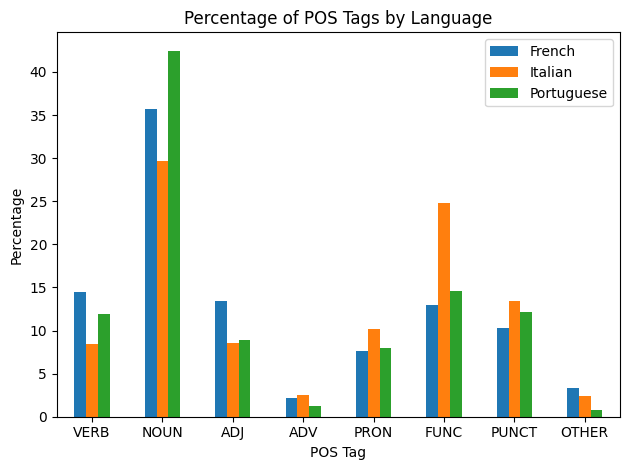

In [16]:
plt.figure(figsize=(10, 6))
plt.grouped_bar = overall_df[['FRENCH_PERCENTAGE', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_PERCENTAGE']].plot(kind='bar')
plt.title('Percentage of POS Tags by Language')
plt.xlabel('POS Tag')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['French', 'Italian', 'Portuguese'])
plt.tight_layout()
plt.show()

### French, Italian, Portuguese, and Genoese: quantitative

In [17]:
genoese_stats = stats(genoese)
print(genoese_stats)

       COUNT  PERCENTAGE
VERB     498   12.938426
NOUN     912   23.694466
ADJ      243    6.313328
ADV      146    3.793193
PRON     669   17.381138
FUNC     698   18.134580
PUNCT    666   17.303196
OTHER     17    0.441673


       FRENCH_COUNT  FRENCH_PERCENTAGE  ITALIAN_COUNT  ITALIAN_PERCENTAGE  \
VERB          542.0          14.418728          319.0            8.403583   
NOUN         1341.0          35.674381         1127.0           29.689146   
ADJ           504.0          13.407821          324.0            8.535300   
ADV            83.0           2.208034           95.0            2.502634   
PRON          288.0           7.661612          386.0           10.168599   
FUNC          488.0          12.982176          942.0           24.815595   
PUNCT         388.0          10.321894          511.0           13.461538   
OTHER         125.0           3.325352           92.0            2.423604   

       PORTUGUESE_COUNT  PORTUGUESE_PERCENTAGE  GENOESE_COUNT  \
VERB              400.0              11.965301          498.0   
NOUN             1420.0              42.476817          912.0   
ADJ               296.0               8.854322          243.0   
ADV                42.0               1.256357

<Figure size 1000x600 with 0 Axes>

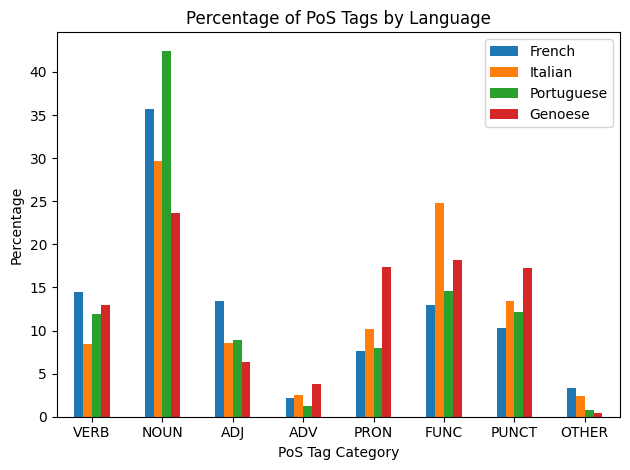

In [18]:
final_df = pd.DataFrame(columns=['FRENCH_COUNT', 'FRENCH_PERCENTAGE', 'ITALIAN_COUNT', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_COUNT', 'PORTUGUESE_PERCENTAGE', 'GENOESE_COUNT', 'GENOESE_PERCENTAGE'])
for pos in POS_GROUPED:
	final_df.loc[pos] = {
		'FRENCH_COUNT': french_stats.loc[pos]['COUNT'],
		'FRENCH_PERCENTAGE': french_stats.loc[pos]['PERCENTAGE'],
		'ITALIAN_COUNT': italian_stats.loc[pos]['COUNT'],
		'ITALIAN_PERCENTAGE': italian_stats.loc[pos]['PERCENTAGE'],
		'PORTUGUESE_COUNT': portuguese_stats.loc[pos]['COUNT'],
		'PORTUGUESE_PERCENTAGE': portuguese_stats.loc[pos]['PERCENTAGE'],
		'GENOESE_COUNT': genoese_stats.loc[pos]['COUNT'],
		'GENOESE_PERCENTAGE': genoese_stats.loc[pos]['PERCENTAGE']
	}
print(final_df)

plt.figure(figsize=(10, 6))
plt.grouped_bar = final_df[['FRENCH_PERCENTAGE', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_PERCENTAGE', 'GENOESE_PERCENTAGE']].plot(kind='bar')
plt.title('Percentage of PoS Tags by Language')
plt.xlabel('PoS Tag Category')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['French', 'Italian', 'Portuguese', 'Genoese'])
plt.tight_layout()
plt.show()

### French, Italian, Portuguese, and Genoese: qualitative

In [19]:
files = {
    'GE': '../csv/postagging_genoese_ORDINATO.csv',
    'IT': '../csv/postagging_italian.csv',
    'FR': '../csv/postagging_french.csv',
    'PT': '../csv/postagging_portuguese.csv',
}

dfs = []
for lang, file in files.items():
	df = pd.read_csv(file)
	rename_cols = {'POS_GROUPED': f'POS_{lang}'}
	df = df.rename(columns=rename_cols)
	df = df[[c for c in df.columns if c in ['SENTENCE', 'TEXT', f'POS_{lang}']]]
	df['word_instance'] = df.groupby('TEXT').cumcount()

	if lang == 'GE':
		df['original_index'] = range(len(df))  # to keep the original order of the sentences for Genoese
	else:
		df = df.drop(columns=['SENTENCE'])  # avoid duplicating the sentence column for the other files

	dfs.append(df)
    
merged_df = dfs[0]
for df in dfs[1:]:
	merged_df = pd.merge(merged_df, df, on=['TEXT', 'word_instance'], how='outer')
drop_cols = [cols for cols in merged_df.columns if '_drop' in cols]
merged_df = merged_df.drop(columns=drop_cols)

if 'original_index' in merged_df.columns:
    merged_df = merged_df.sort_values('original_index')
    merged_df = merged_df.drop(columns=['original_index'])

merged_df = merged_df.drop(columns=['word_instance']) # remove technical column
for col in merged_df.columns:
	if col.startswith('POS_'):
		merged_df[col] = merged_df[col].fillna('NA')
merged_df.to_csv('../csv/postagging_merged.csv', index=False)
merged_df.head()

,SENTENCE,TEXT,POS_GE,POS_IT,POS_FR,POS_PT
803,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,PRON,NOUN,NOUN,PRON
1018,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,NOUN,NOUN,NOUN,NOUN
541,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,NOUN,NOUN,NOUN,NOUN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT,PUNCT,PUNCT,PUNCT
3248,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,PRON,FUNC,FUNC,PRON


In [20]:
def evaluation(df):
	IT_correct = 0
	FR_correct = 0
	PT_correct = 0

	IT_null = 0
	FR_null = 0
	PT_null = 0

	for _, row in df.iterrows():

		if row['POS_GE'] == row['POS_IT']:
			IT_correct += 1
		if row['POS_GE'] == row['POS_FR']:
			FR_correct += 1
		if row['POS_GE'] == row['POS_PT']:
			PT_correct += 1

		if row['POS_IT'] == 'NA':
			IT_null += 1
		if row['POS_FR'] == 'NA':
			FR_null += 1
		if row['POS_PT'] == 'NA':
			PT_null += 1

	return IT_correct, FR_correct, PT_correct, IT_null, FR_null, PT_null

In [21]:
IT_correct, FR_correct, PT_correct, IT_null, FR_null, PT_null = evaluation(merged_df)
total = len(merged_df)

perc_correct_IT = IT_correct / total * 100
perc_correct_FR = FR_correct / total * 100
perc_correct_PT = PT_correct / total * 100
perc_null_IT = IT_null / total * 100
perc_null_FR = FR_null / total * 100
perc_null_PT = PT_null / total * 100

print(f"IT: {perc_correct_IT:.2f}% correct ({IT_correct}/{total}), {perc_null_IT:.2f}% null ({IT_null}/{total})")
print(f"FR: {perc_correct_FR:.2f}% correct ({FR_correct}/{total}), {perc_null_FR:.2f}% null ({FR_null}/{total})")
print(f"PT: {perc_correct_PT:.2f}% correct ({PT_correct}/{total}), {perc_null_PT:.2f}% null ({PT_null}/{total})")

IT: 49.11% correct (2288/4659), 18.52% null (863/4659)
FR: 39.36% correct (1834/4659), 19.32% null (900/4659)
PT: 52.44% correct (2443/4659), 28.25% null (1316/4659)


In [22]:
def countPOS(df):
	NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER = 0, 0, 0, 0, 0, 0, 0, 0
	for _, row in df.iterrows():
		pos = row['POS_GE']
		if pos == 'NOUN':
			NOUN += 1
		elif pos == 'VERB':
			VERB += 1
		elif pos == 'ADJ':
			ADJ += 1
		elif pos == 'PRON':
			PRON += 1
		elif pos == 'ADV':
			ADV += 1
		elif pos == 'PUNCT':
			PUNCT += 1
		elif pos == 'FUNC':
			FUNC += 1
		elif pos == 'OTHER':
			OTHER += 1
	return NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER

NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER = countPOS(merged_df)

In [23]:
def modified_evaluation_IT(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_IT']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_IT, VERB_correct_IT, ADJ_correct_IT, PRON_correct_IT, ADV_correct_IT, PUNCT_correct_IT, FUNC_correct_IT, OTHER_correct_IT = modified_evaluation_IT(merged_df)

In [24]:
def modified_evaluation_FR(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_FR']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_FR, VERB_correct_FR, ADJ_correct_FR, PRON_correct_FR, ADV_correct_FR, PUNCT_correct_FR, FUNC_correct_FR, OTHER_correct_FR = modified_evaluation_FR(merged_df)

In [25]:
def modified_evaluation_PT(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_PT']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_PT, VERB_correct_PT, ADJ_correct_PT, PRON_correct_PT, ADV_correct_PT, PUNCT_correct_PT, FUNC_correct_PT, OTHER_correct_PT = modified_evaluation_PT(merged_df)

In [26]:
print(f"IT: NOUN {NOUN_correct_IT}/{NOUN}, VERB {VERB_correct_IT}/{VERB}, ADJ {ADJ_correct_IT}/{ADJ}, PRON {PRON_correct_IT}/{PRON}, ADV {ADV_correct_IT}/{ADV}, PUNCT {PUNCT_correct_IT}/{PUNCT}, FUNC {FUNC_correct_IT}/{FUNC}, OTHER {OTHER_correct_IT}/{OTHER}")
print(f"FR: NOUN {NOUN_correct_FR}/{NOUN}, VERB {VERB_correct_FR}/{VERB}, ADJ {ADJ_correct_FR}/{ADJ}, PRON {PRON_correct_FR}/{PRON}, ADV {ADV_correct_FR}/{ADV}, PUNCT {PUNCT_correct_FR}/{PUNCT}, FUNC {FUNC_correct_FR}/{FUNC}, OTHER {OTHER_correct_FR}/{OTHER}")
print(f"PT: NOUN {NOUN_correct_PT}/{NOUN}, VERB {VERB_correct_PT}/{VERB}, ADJ {ADJ_correct_PT}/{ADJ}, PRON {PRON_correct_PT}/{PRON}, ADV {ADV_correct_PT}/{ADV}, PUNCT {PUNCT_correct_PT}/{PUNCT}, FUNC {FUNC_correct_PT}/{FUNC}, OTHER {OTHER_correct_PT}/{OTHER}")

IT: NOUN 766/912, VERB 162/498, ADJ 133/243, PRON 103/669, ADV 38/146, PUNCT 409/666, FUNC 420/698, OTHER 0/17
FR: NOUN 601/912, VERB 97/498, ADJ 116/243, PRON 79/669, ADV 9/146, PUNCT 386/666, FUNC 231/698, OTHER 4/17
PT: NOUN 645/912, VERB 139/498, ADJ 82/243, PRON 241/669, ADV 11/146, PUNCT 406/666, FUNC 362/698, OTHER 0/17


In [27]:
# percentages
perc_correct_NOUN_IT = NOUN_correct_IT / NOUN * 100
perc_correct_VERB_IT = VERB_correct_IT / VERB * 100
perc_correct_ADJ_IT = ADJ_correct_IT / ADJ * 100
perc_correct_PRON_IT = PRON_correct_IT / PRON * 100
perc_correct_ADV_IT = ADV_correct_IT / ADV * 100
perc_correct_PUNCT_IT = PUNCT_correct_IT / PUNCT * 100
perc_correct_FUNC_IT = FUNC_correct_IT / FUNC * 100
perc_correct_OTHER_IT = OTHER_correct_IT / OTHER * 100

perc_correct_NOUN_FR = NOUN_correct_FR / NOUN * 100
perc_correct_VERB_FR = VERB_correct_FR / VERB * 100
perc_correct_ADJ_FR = ADJ_correct_FR / ADJ * 100
perc_correct_PRON_FR = PRON_correct_FR / PRON * 100
perc_correct_ADV_FR = ADV_correct_FR / ADV * 100
perc_correct_PUNCT_FR = PUNCT_correct_FR / PUNCT * 100
perc_correct_FUNC_FR = FUNC_correct_FR / FUNC * 100
perc_correct_OTHER_FR = OTHER_correct_FR / OTHER * 100

perc_correct_NOUN_PT = NOUN_correct_PT / NOUN * 100
perc_correct_VERB_PT = VERB_correct_PT / VERB * 100
perc_correct_ADJ_PT = ADJ_correct_PT / ADJ * 100
perc_correct_PRON_PT = PRON_correct_PT / PRON * 100
perc_correct_ADV_PT = ADV_correct_PT / ADV * 100
perc_correct_PUNCT_PT = PUNCT_correct_PT / PUNCT * 100
perc_correct_FUNC_PT = FUNC_correct_PT / FUNC * 100
perc_correct_OTHER_PT = OTHER_correct_PT / OTHER * 100

print(f"IT: NOUN {perc_correct_NOUN_IT:.2f}%, VERB {perc_correct_VERB_IT:.2f}%, ADJ {perc_correct_ADJ_IT:.2f}%, PRON {perc_correct_PRON_IT:.2f}%, ADV {perc_correct_ADV_IT:.2f}%, PUNCT {perc_correct_PUNCT_IT:.2f}%, FUNC {perc_correct_FUNC_IT:.2f}%, OTHER {perc_correct_OTHER_IT:.2f}%")
print(f"FR: NOUN {perc_correct_NOUN_FR:.2f}%, VERB {perc_correct_VERB_FR:.2f}%, ADJ {perc_correct_ADJ_FR:.2f}%, PRON {perc_correct_PRON_FR:.2f}%, ADV {perc_correct_ADV_FR:.2f}%, PUNCT {perc_correct_PUNCT_FR:.2f}%, FUNC {perc_correct_FUNC_FR:.2f}%, OTHER {perc_correct_OTHER_FR:.2f}%")
print(f"PT: NOUN {perc_correct_NOUN_PT:.2f}%, VERB {perc_correct_VERB_PT:.2f}%, ADJ {perc_correct_ADJ_PT:.2f}%, PRON {perc_correct_PRON_PT:.2f}%, ADV {perc_correct_ADV_PT:.2f}%, PUNCT {perc_correct_PUNCT_PT:.2f}%, FUNC {perc_correct_FUNC_PT:.2f}%, OTHER {perc_correct_OTHER_PT:.2f}%")

IT: NOUN 83.99%, VERB 32.53%, ADJ 54.73%, PRON 15.40%, ADV 26.03%, PUNCT 61.41%, FUNC 60.17%, OTHER 0.00%
FR: NOUN 65.90%, VERB 19.48%, ADJ 47.74%, PRON 11.81%, ADV 6.16%, PUNCT 57.96%, FUNC 33.09%, OTHER 23.53%
PT: NOUN 70.72%, VERB 27.91%, ADJ 33.74%, PRON 36.02%, ADV 7.53%, PUNCT 60.96%, FUNC 51.86%, OTHER 0.00%


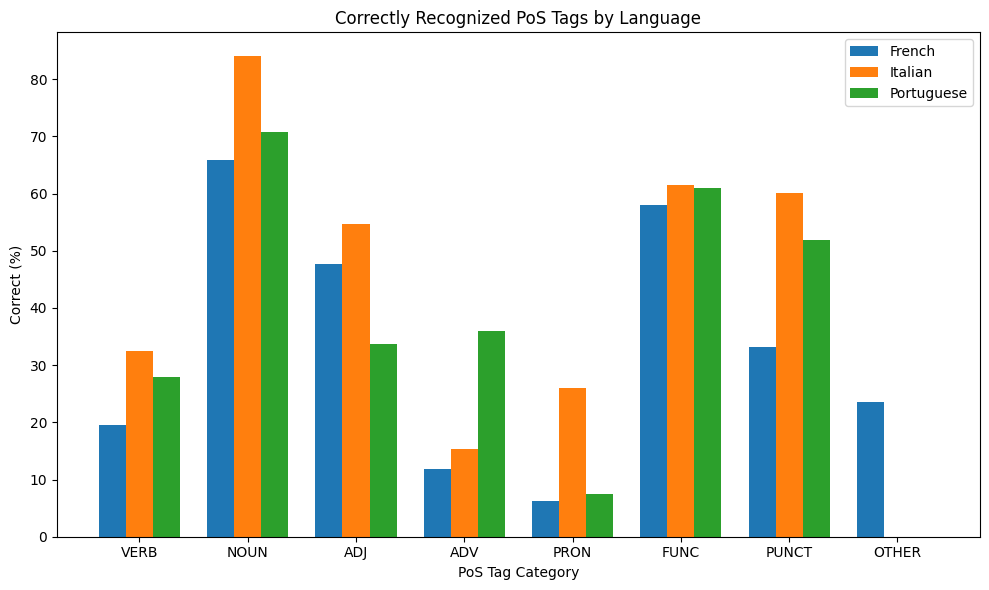

In [28]:
labels = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PRON',  'FUNC', 'PUNCT', 'OTHER']
x = list(range(len(labels)))
width = 0.25

it_vals = [perc_correct_VERB_IT, perc_correct_NOUN_IT, perc_correct_ADJ_IT, perc_correct_PRON_IT, perc_correct_ADV_IT, perc_correct_PUNCT_IT, perc_correct_FUNC_IT, perc_correct_OTHER_IT]
fr_vals = [perc_correct_VERB_FR, perc_correct_NOUN_FR, perc_correct_ADJ_FR, perc_correct_PRON_FR, perc_correct_ADV_FR, perc_correct_PUNCT_FR, perc_correct_FUNC_FR, perc_correct_OTHER_FR]
pt_vals = [perc_correct_VERB_PT, perc_correct_NOUN_PT, perc_correct_ADJ_PT, perc_correct_PRON_PT, perc_correct_ADV_PT, perc_correct_PUNCT_PT, perc_correct_FUNC_PT, perc_correct_OTHER_PT]

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], fr_vals, width=width, label='French')
plt.bar(x, it_vals, width=width, label='Italian')
plt.bar([i + width for i in x], pt_vals, width=width, label='Portuguese')

plt.xticks(x, labels)
plt.xlabel('PoS Tag Category')
plt.ylabel('Correct (%)')
plt.title('Correctly Recognized PoS Tags by Language')
plt.legend()
plt.tight_layout()

In [29]:
# differences between languages
for i in range(len(labels)):
	diff_it_fr = abs(it_vals[i] - fr_vals[i])
	diff_it_pt = abs(it_vals[i] - pt_vals[i])
	diff_fr_pt = abs(fr_vals[i] - pt_vals[i])
	print(f"{labels[i]}: IT-FR {diff_it_fr:.2f}%, IT-PT {diff_it_pt:.2f}%, FR-PT {diff_fr_pt:.2f}%, average {((diff_it_fr + diff_it_pt + diff_fr_pt) / 3):.2f}%")

VERB: IT-FR 13.05%, IT-PT 4.62%, FR-PT 8.43%, average 8.70%
NOUN: IT-FR 18.09%, IT-PT 13.27%, FR-PT 4.82%, average 12.06%
ADJ: IT-FR 7.00%, IT-PT 20.99%, FR-PT 13.99%, average 13.99%
ADV: IT-FR 3.59%, IT-PT 20.63%, FR-PT 24.22%, average 16.14%
PRON: IT-FR 19.86%, IT-PT 18.49%, FR-PT 1.37%, average 13.24%
FUNC: IT-FR 3.45%, IT-PT 0.45%, FR-PT 3.00%, average 2.30%
PUNCT: IT-FR 27.08%, IT-PT 8.31%, FR-PT 18.77%, average 18.05%
OTHER: IT-FR 23.53%, IT-PT 0.00%, FR-PT 23.53%, average 15.69%
